In [1]:
from notebook_functions import *

In [2]:
import intake
from easygems import healpix as egh

In [3]:
data_dict={}

In [4]:
for region in ["WAf","US","India"]:
    for res in ["10km","5km"]:
        mcs=pd.read_csv(f"~/Huracan/Hackathons/{res}-CoMA9_{region}_MCS_envs.csv")
        mcs["time"]=pd.to_datetime(mcs["time"])
        mcs["hour"]=mcs.time.dt.hour
        mcs["tmin"]=mcs["tmin"]-273
        if region=="US":
            for var in mcs.filter(regex="ushear").columns:
                mcs[var]=-1*mcs[var]
        data_dict[region+res]=mcs

2302
2302
2302
2302


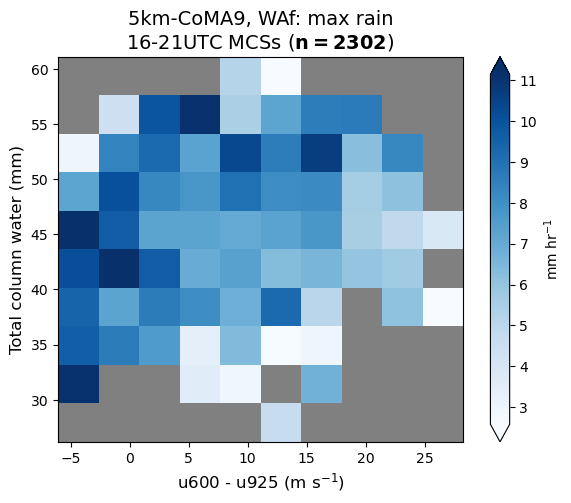

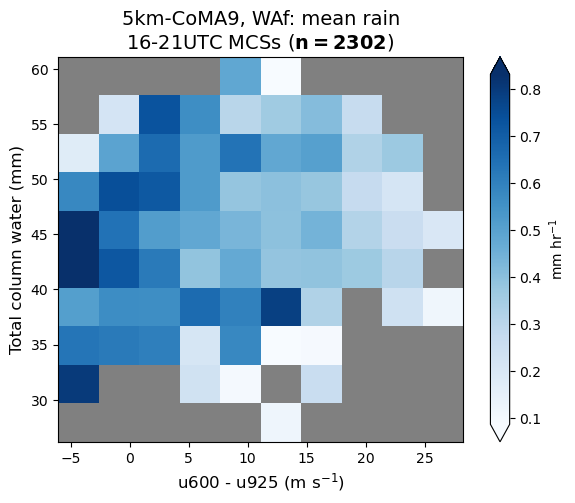

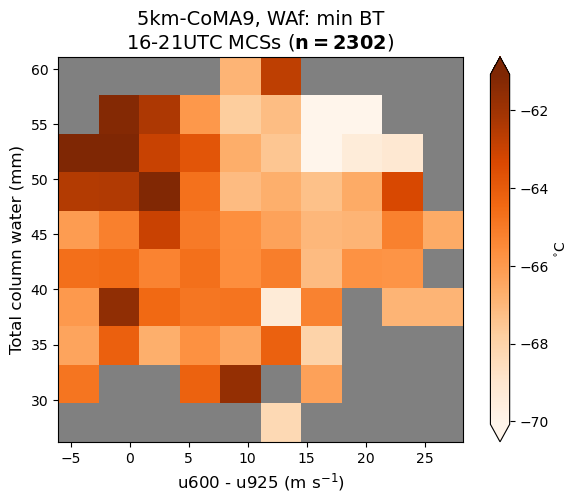

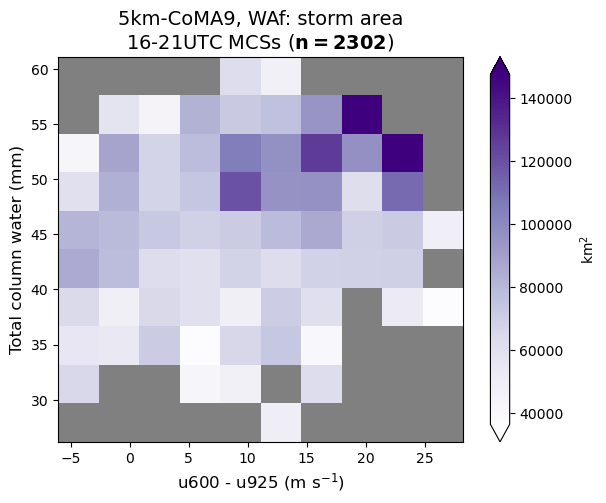

In [5]:
region,res="WAf","5km"
for var in ["rain_max","rain_mean","tmin","area"]:
    plot_hist(data_dict[region+res],region,res+"-CoMA9",var,shear_var="ushear600_925",moist_var="tcw")

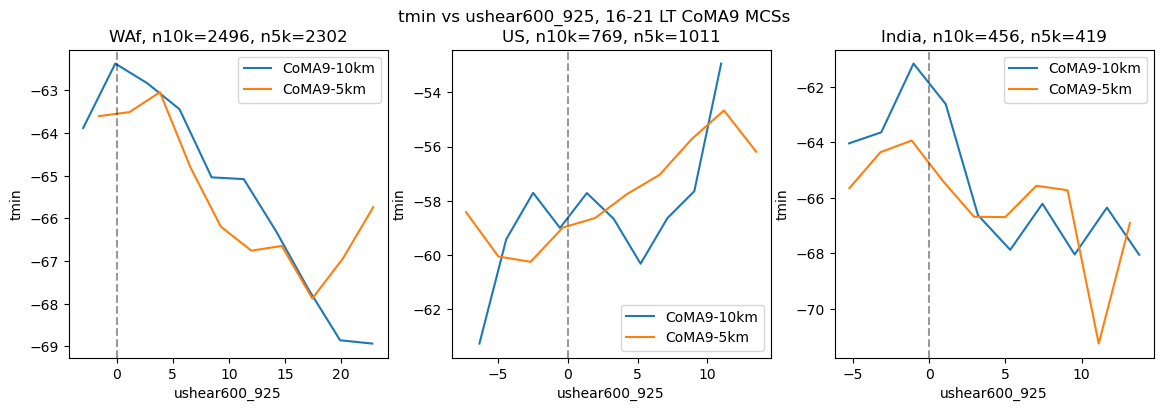

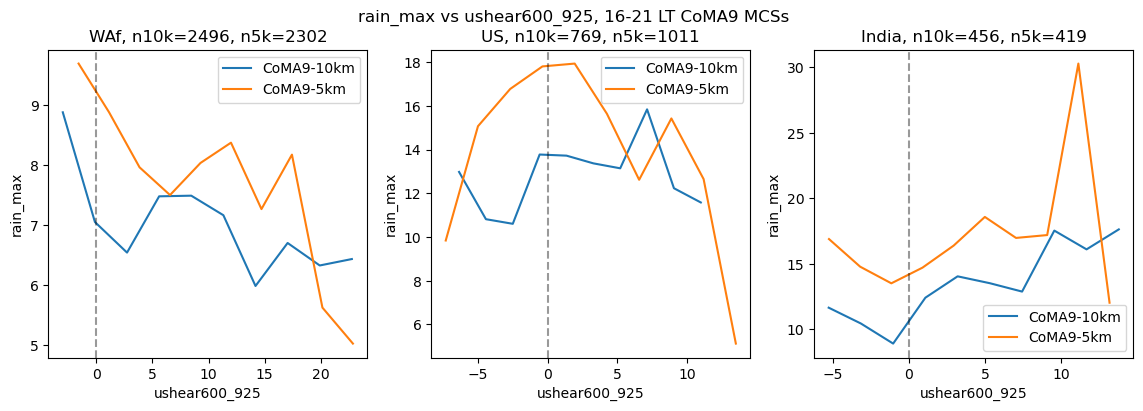

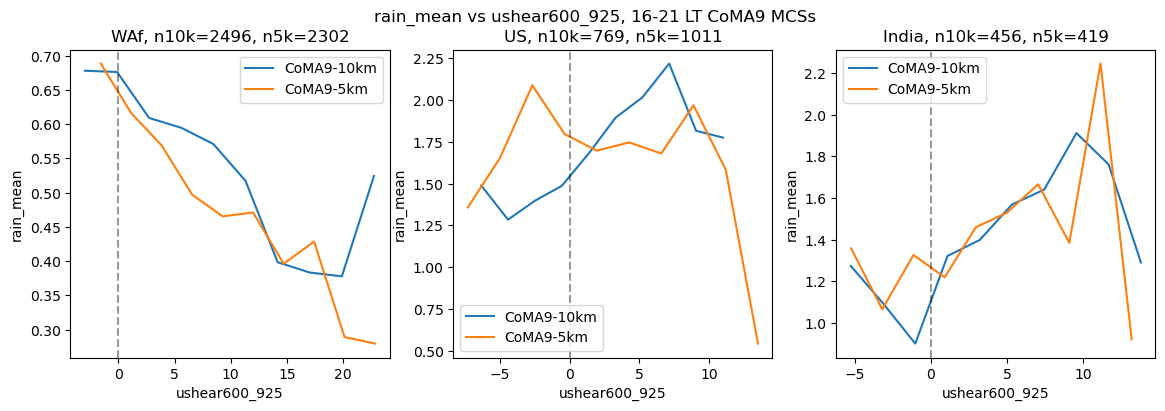

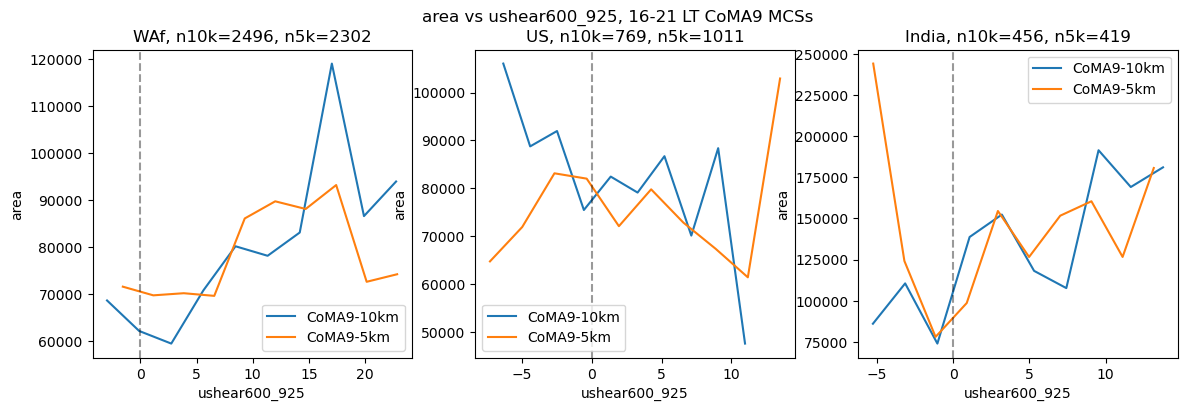

In [6]:
bin_var="ushear600_925"
for mcs_var in ["tmin","rain_max","rain_mean","area"]:
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    for i,region in enumerate(["WAf","US","India"]):
        ax=axes[i]
        out10k=bin_1d(data_dict[region+"10km"],mcs_var,bin_var,"tcw",min_pcle=0.05,max_pcle=0.95)
        out5k=bin_1d(data_dict[region+"5km"],mcs_var,bin_var,"tcw",min_pcle=0.05,max_pcle=0.95)
        
        out10k[0].plot(ax=ax,label="CoMA9-10km")
        out5k[0].plot(ax=ax,label="CoMA9-5km")
        
        ax.set_title(f"{region}, n10k={len(data_dict[region+"10km"])}, n5k={len(data_dict[region+"5km"])}")
        ax.set_xlabel(bin_var)
        ax.set_ylabel(mcs_var)
        ax.axvline(0,color="k",ls="--",alpha=0.4)
        ax.legend()
    fig.suptitle(f"{mcs_var} vs {bin_var}, 16-21 LT CoMA9 MCSs")

In [7]:
mcs_bm=pd.read_csv("~/Huracan/Hackathons/10km-CoMA9_WAf_MCS_envsBMtracks.csv")
mcs_bm["time"]=pd.to_datetime(mcs_bm["time"])
mcs_bm["hour"]=mcs_bm.time.dt.hour

In [8]:
mcs_bm=mcs_bm.rename(columns={"rainmax":"rain_max"})

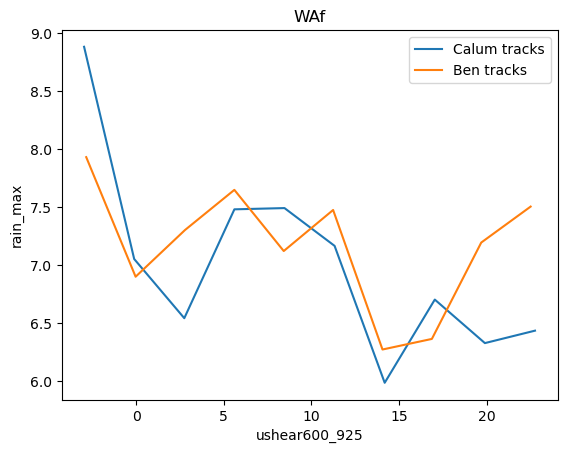

In [9]:
bin_var,mcs_var="ushear600_925","rain_max"
out10k=bin_1d(data_dict["WAf10km"],mcs_var,bin_var,"tcw",min_pcle=0.05,max_pcle=0.95)
out10k_bm=bin_1d(mcs_bm,mcs_var,bin_var,"tcw",min_pcle=0.05,max_pcle=0.95)
        
out10k[0].plot(label="Calum tracks")
out10k_bm[0].plot(label="Ben tracks")
plt.title("WAf")
plt.xlabel(bin_var)
plt.ylabel(mcs_var)
plt.legend()

Text(0.5, 1, 'MCS maximum rainfall vs shear, 16-21 LT CoMA9 MCSs')

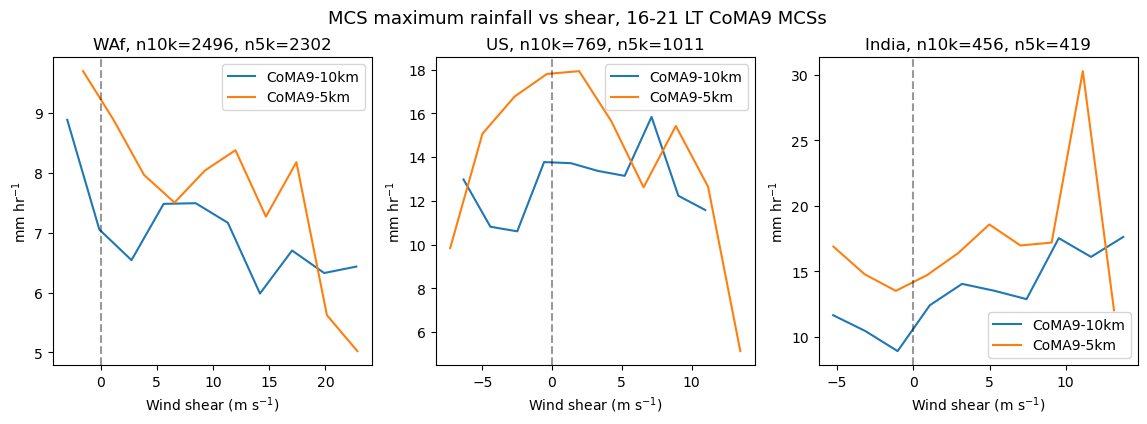

In [10]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
mcs_var="rain_max"
for i,region in enumerate(["WAf","US","India"]):
    ax=axes[i]
    out10k=bin_1d(data_dict[region+"10km"],mcs_var,bin_var,"tcw",min_pcle=0.05,max_pcle=0.95)
    out5k=bin_1d(data_dict[region+"5km"],mcs_var,bin_var,"tcw",min_pcle=0.05,max_pcle=0.95)
    
    out10k[0].plot(ax=ax,label="CoMA9-10km")
    out5k[0].plot(ax=ax,label="CoMA9-5km")
    
    ax.set_title(f"{region}, n10k={len(data_dict[region+"10km"])}, n5k={len(data_dict[region+"5km"])}")
    ax.set_xlabel("Wind shear (m s$^{-1}$)")
    ax.set_ylabel("mm hr$^{-1}$")
    ax.axvline(0,color="k",ls="--",alpha=0.4)
    ax.legend()
fig.suptitle(f"MCS maximum rainfall vs shear, 16-21 LT CoMA9 MCSs", y=1,fontsize=13)

In [11]:
MCS_datas=[mcs_10k,mcs_5k]
obs_mcs=[]
for ffile in glob.glob("/gws/nopw/j04/kscale/USERS/bmaybee/simpleTrack_MCS_outputs/obs_ea-waf_MCS_tracks_rain_*_reformat.csv"): # from tracks run by Ashar
    mcs=pd.read_csv(ffile)
    mcs["time"]=pd.to_datetime(mcs.time)
    mcs=mcs[mcs.area>15000]
    mcs["hour"]=mcs.time.dt.hour
    ltimes=mcs["area"].groupby(mcs.storm_id).count()
    area_max=mcs["area"].groupby(mcs.storm_id).max()
    obs_mcs.append(mcs[(mcs.storm_id.isin(ltimes[ltimes>5].index)) & (mcs.storm_id.isin(mcs[mcs.rainmax>10].storm_id)) & 
                                    (mcs.storm_id.isin(mcs[mcs.rainvol*11.1**2 > 20000].storm_id)) & (mcs.storm_id.isin(area_max[area_max>40000].index))])
obs_mcs=pd.concat(obs_mcs)
obs_mcs["rain_mean"]=obs_mcs["rainvol"]/(obs_mcs["area"]/11.1**2)

NameError: name 'mcs_10k' is not defined

In [ ]:
def spatial_binning(MCS_data,region="Wafrica",var="count",res=1,shear="ushear600_850",q="tcw",max_pcle=0.99,min_pcle=0.01):
    if region=="Wafrica":
        xbin = np.arange(-18, 25,res) # should be 18 to 25 
        ybin = np.arange(4,25,res) #should be 4 to 25
    elif region=="Sahel":
        xbin = np.arange(-12,12,res)
        ybin = np.arange(9,19,res)
    elif region == "India":
        xbin = np.arange(70, 91,res) 
        ybin = np.arange(5,31,res) 
    plotbins = [xbin,ybin]
    
    #MCS_data=MCS_data[(MCS_data[shear]>MCS_data[shear].quantile(min_pcle)) & (MCS_data[shear]<MCS_data[shear].quantile(max_pcle)) & 
    #                    (MCS_data[q]>MCS_data[q].quantile(min_pcle)) & (MCS_data[q]<MCS_data[q].quantile(max_pcle))]
    dist = stats.binned_statistic_2d(MCS_data["clon"],MCS_data["clat"],MCS_data["area"],"count",bins=plotbins)
    da=xr.DataArray(dist.statistic,coords=[xbin[:-1]+res/2,ybin[:-1]+res/2],dims=["longitude","latitude"])
    #res/2 offset ensures coordinates are the centres of the bins, not lowest edge
    if var!="count":
        if var[-4:] == "norm":
            dist_var = stats.binned_statistic_2d(MCS_data["clon"],MCS_data["clat"],MCS_data[var[:-5]],"mean",bins=plotbins)
            dist_var = dist_var.statistic/MCS_data[var[:-5]].mean()
        elif var[-4:] == "anom":
            MCS_data[var] = MCS_data[var[:-5]] - MCS_data[var[:-5]].mean()#*np.ones(len(MCS_data[var[:-5]]))
            dist_var = stats.binned_statistic_2d(MCS_data["clon"],MCS_data["clat"],MCS_data[var],"mean",bins=plotbins).statistic
        else:
            dist_var = stats.binned_statistic_2d(MCS_data["clon"],MCS_data["clat"],MCS_data[var],"mean",bins=plotbins).statistic
        da_var = xr.DataArray(dist_var,coords=[xbin[:-1]+res/2,ybin[:-1]+res/2],dims=["longitude","latitude"])
        da = da_var.where(da>0)
    
    #counts=xr.DataArray(dist.statistic,coords=[xbin[:-1],ybin[:-1]],dims=["longitude","latitude"])
    return da

In [ ]:
fig,axes=plt.subplots(2,figsize=(8,8),subplot_kw=dict(projection=ccrs.PlateCarree()),gridspec_kw={"hspace":0.1})
lens,corrs=[],[]
mod="_anom"
rain_var="rain_mean"
res=2.5
for i, sim in enumerate(["10km-CoMA9","5km-CoMA9"]):
    MCS_data=MCS_datas[i]
    plev=850
    #MCS_data=MCS_data[MCS_data["psfc"]>plev]
    biases=spatial_binning(MCS_data,var=rain_var+mod,res=res,max_pcle=0.95,min_pcle=0.05) - spatial_binning(
                        obs_mcs,var=rain_var+mod,res=res,max_pcle=0.95,min_pcle=0.05)
    biases=biases/spatial_binning(obs_mcs,var=rain_var,res=res,max_pcle=0.95,min_pcle=0.05)*100
    biases.T.plot(ax=axes[i],cmap="RdBu",extend="both",
                  cbar_kwargs={"shrink":0.8,"label":r"MCS {} rainfall bias (%)".format(rain_var.split("_")[-1])},vmax=125,vmin=-125)
    
    axes[i].coastlines()
    gl = axes[i].gridlines(crs = ccrs.PlateCarree(),draw_labels=True,linestyle="--")
    gl.ylines = False
    gl.top_labels = False
    gl.right_labels = False
    gl.ylocator = mticker.FixedLocator([5,10,15,20])
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    axes[i].set_facecolor("lightgrey")
    axes[i].plot((-17.8,-17.8),(9,19),color="orchid",linewidth=4)
    axes[i].set_xlim([-18,24])
    axes[i].plot((23.8,23.8),(9,19),color="orchid",linewidth=4)
    lens.append(len(MCS_data))
    #axes[i].set_xlim([-17.5,24.5])
    #axes[i].set_ylim([4.5,24.5])
    axes[i].set_title(sim)
axes[0].text(-22.5,12.6,"Sahel",rotation="vertical",ha="center",fontsize=12,color="darkorchid")
#fig.savefig("fig4c.png",dpi=250,bbox_inches="tight",facecolor="white")